# Compressive Strength — Phase 0 + Phase 1 (Honest Baseline)

**Goal of this notebook:** stop trusting the single-split R² numbers from `CompressiveStrength_ML_Results.xlsx` and replace them with cross-validated, group-aware estimates so we know what the train/val/test gap *really* is.

Phases covered:
- **Phase 0** — load & clean the source xlsx, audit the 21 `N\A` target rows, EDA, detect near-duplicate base mixes (group ids).
- **Phase 1** — reproduce the 7 baseline models (Linear, RF, GB, AdaBoost, CatBoost, LightGBM, XGBoost) with **Repeated K-Fold CV** (random) and **GroupKFold CV**. Compare against the old single-split numbers.

Nothing in this notebook tries to *improve* the models — only to measure them honestly. Improvements come in later phases.

## Phase 0.1 — Imports and load

In [1]:
import sys, os
sys.path.insert(0, '/Users/fakhirhassan/Desktop/CivilFYP')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import civil_utils as cu

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

raw = cu.load_clean(cu.CS_FILE, cu.CS_TARGET)
print('Raw shape:', raw.shape)
print('Columns:', list(raw.columns))
raw.head()

Raw shape: (84, 16)
Columns: ['flyash', 'ggbfs', 'curing_temp_c', 'curing_time_hr', 'na2sio3', 'naoh', 'na2sio3_naoh_ratio', 'naoh_molarity', 'activator_binder_ratio', 'water', 'sp', 'nca', 'rca', 'sand', 'r_sand', 'compressive_strength_mpa']


,flyash,ggbfs,curing_temp_c,curing_time_hr,na2sio3,naoh,na2sio3_naoh_ratio,naoh_molarity,activator_binder_ratio,water,sp,nca,rca,sand,r_sand,compressive_strength_mpa
0,420.0000,0.0000,75.0000,24.0000,165.0000,66.0000,2.5000,14.0000,0.5500,0.0000,0.0000,"1,220.0000",0.0000,550.0000,0.0000,26.1000
1,378.0000,42.0000,75.0000,24.0000,165.0000,66.0000,2.5000,14.0000,0.5500,0.0000,0.0000,"1,220.0000",0.0000,550.0000,0.0000,43.5000
2,336.0000,84.0000,75.0000,24.0000,165.0000,66.0000,2.5000,14.0000,0.5500,0.0000,0.0000,"1,220.0000",0.0000,550.0000,0.0000,47.0000
3,294.0000,126.0000,75.0000,24.0000,165.0000,66.0000,2.5000,14.0000,0.5500,0.0000,0.0000,"1,220.0000",0.0000,550.0000,0.0000,52.3000
4,420.0000,0.0000,75.0000,24.0000,165.0000,66.0000,2.5000,14.0000,0.5500,0.0000,0.0000,610.0000,610.0000,550.0000,0.0000,14.0000


## Phase 0.2 — Audit the missing/non-numeric target rows

The previous results overview claimed 353 samples but the file has 84 records. 21 rows have `N\A` or NaN in the target. We document them here and then drop, so the working dataset is fully reproducible.

In [2]:
missing_mask = raw[cu.CS_TARGET].isna()
print(f'Rows with missing target: {missing_mask.sum()} / {len(raw)}')
print(f'Rows with valid target  : {(~missing_mask).sum()}')
raw.loc[missing_mask, ['flyash','ggbfs','curing_temp_c','curing_time_hr','activator_binder_ratio',cu.CS_TARGET]]

Rows with missing target: 20 / 84
Rows with valid target  : 64


,flyash,ggbfs,curing_temp_c,curing_time_hr,activator_binder_ratio,compressive_strength_mpa
12,333.0000,333.0000,80.0000,24.0000,0.3000,NaN
13,333.0000,333.0000,80.0000,24.0000,0.3000,NaN
14,333.0000,333.0000,80.0000,24.0000,0.3000,NaN
15,333.0000,333.0000,80.0000,24.0000,0.3000,NaN
17,250.0000,250.0000,80.0000,24.0000,0.4000,NaN
18,250.0000,250.0000,80.0000,24.0000,0.4000,NaN
19,250.0000,250.0000,80.0000,24.0000,0.4000,NaN
20,250.0000,250.0000,80.0000,24.0000,0.4000,NaN
22,200.0000,200.0000,80.0000,24.0000,0.5000,NaN
23,200.0000,200.0000,80.0000,24.0000,0.5000,NaN


In [3]:
df = cu.cs_dataset(drop_na_target=True)
print('Working dataset shape:', df.shape)
print(f'Features: {len(df.columns) - 1} | Samples: {len(df)}')
df.describe().T

Working dataset shape: (64, 16)
Features: 15 | Samples: 64


,count,mean,std,min,25%,50%,75%,max
flyash,64.0000,321.6250,117.1304,0.0000,250.0000,334.5000,420.0000,500.0000
ggbfs,64.0000,106.8594,115.0861,0.0000,0.0000,82.0000,132.0000,500.0000
curing_temp_c,64.0000,43.9219,23.9585,0.0000,25.5000,27.0000,60.0000,80.0000
curing_time_hr,64.0000,15.3750,15.6342,0.0000,0.0000,24.0000,24.0000,48.0000
na2sio3,64.0000,142.3806,41.1414,0.0000,109.5500,147.8600,165.0000,195.0000
naoh,64.0000,63.6306,26.0826,0.0000,53.0000,66.0000,78.5000,108.0000
na2sio3_naoh_ratio,64.0000,2.5517,1.4880,0.0000,1.8001,2.5000,2.5000,7.9300
naoh_molarity,64.0000,12.2109,2.8768,0.0000,11.5000,12.0000,14.0000,16.0000
activator_binder_ratio,64.0000,0.5859,0.4188,0.0000,0.4000,0.5000,0.6000,2.7300
water,64.0000,29.2203,39.2308,0.0000,0.0000,0.0000,62.0000,122.0000


## Phase 0.3 — Target distribution + near-constant feature check

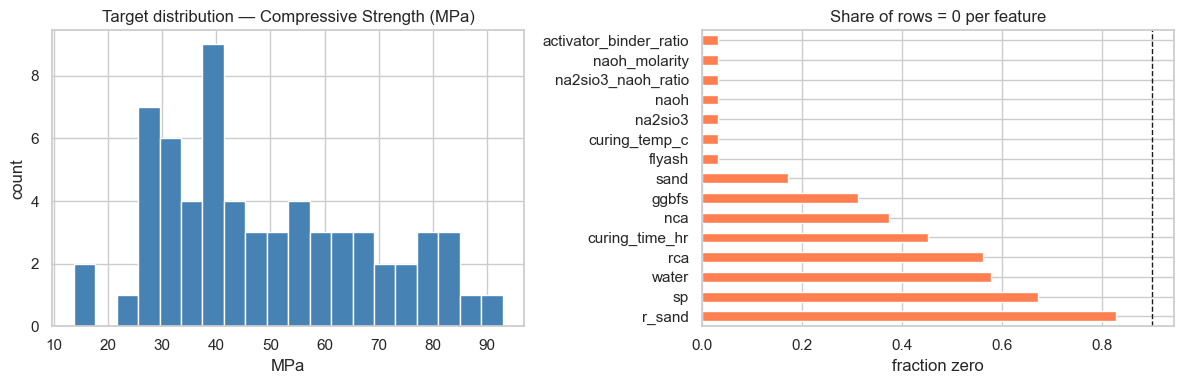


Features with >= 90% zeros (candidates to drop):
Series([], dtype: float64)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[cu.CS_TARGET], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Target distribution — Compressive Strength (MPa)')
axes[0].set_xlabel('MPa'); axes[0].set_ylabel('count')

# Near-constant features: how many rows are zero in each column?
zero_share = (df.drop(columns=[cu.CS_TARGET]) == 0).mean().sort_values(ascending=False)
zero_share.plot.barh(ax=axes[1], color='coral')
axes[1].set_title('Share of rows = 0 per feature')
axes[1].set_xlabel('fraction zero'); axes[1].axvline(0.9, color='k', ls='--', lw=1)
plt.tight_layout(); plt.show()
print('\nFeatures with >= 90% zeros (candidates to drop):')
print(zero_share[zero_share >= 0.9])

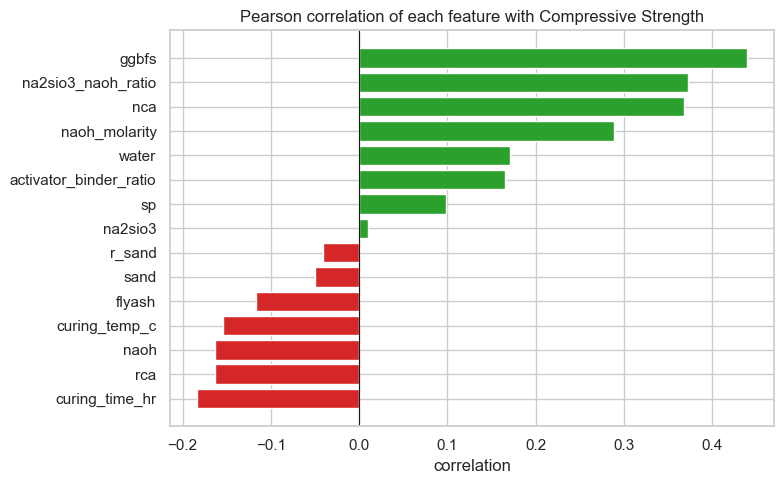

In [5]:
corr = df.corr(numeric_only=True)[cu.CS_TARGET].drop(cu.CS_TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_title('Pearson correlation of each feature with Compressive Strength')
ax.set_xlabel('correlation'); ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

## Phase 0.4 — Detect near-duplicate base mixes (group ids)

A random train/test split treats each row as independent. But many rows in this dataset are *the same base mix with one variable changed* (e.g. different curing temperature, different aggregate). If we let those rows sit in both train and test, the model sees something almost identical to the test row during training and the "test R²" inflates.

We assign a `group_id` per unique (binder + activator) recipe and use **GroupKFold** so the same recipe never crosses folds.

In [6]:
X, y = cu.feature_target_split(df, cu.CS_TARGET)
group_ids = cu.assign_group_ids(X)
n_groups = len(np.unique(group_ids))
group_sizes = pd.Series(group_ids).value_counts().sort_values(ascending=False)
print(f'Rows: {len(X)} | Unique base-mix groups: {n_groups}')
print(f'Mean rows per group: {group_sizes.mean():.2f} | Max: {group_sizes.max()} | Median: {group_sizes.median():.0f}')
print('\nTop 10 groups by size:')
print(group_sizes.head(10).to_string())

Rows: 64 | Unique base-mix groups: 47
Mean rows per group: 1.36 | Max: 5 | Median: 1

Top 10 groups by size:
7     5
2     3
3     3
1     3
0     3
10    2
8     2
24    2
20    2
9     2


---
## Phase 1 — Honest baseline via Cross-Validation

For every model we score it under **two CV regimes**:

1. **Repeated KFold (random)** — 5 folds × 5 repeats = 25 outer folds. Each outer fold's hold-out becomes TEST; the remaining ~80% is split 80/20 into TRAIN/VAL. Reports mean ± std of R² across all folds.
2. **GroupKFold** — 5 folds, splitting on `group_id` so the same base mix can't appear in train and test. This is the *honest* number — if it's much lower than (1), the original single-split numbers were inflated by mix-design leakage.

Same model defaults as the previous results spreadsheet (so they are directly comparable).

In [7]:
zoo = cu.default_model_zoo()
print('Models that will be evaluated:')
for k in zoo:
    print(f'  - {k}')

Models that will be evaluated:
  - Linear Regression
  - Random Forest
  - Gradient Boosting
  - AdaBoost
  - CatBoost
  - LightGBM
  - XGBoost


In [8]:
random_rows, group_rows = [], []

for name, factory in zoo.items():
    print(f'  evaluating {name} ...', flush=True)
    fs_rand = cu.cv_evaluate(factory, X, y, groups=None,
                             n_splits=5, n_repeats=5, random_state=0)
    random_rows.append(fs_rand.summary_row(name))

    fs_grp = cu.cv_evaluate(factory, X, y, groups=group_ids,
                            n_splits=5, n_repeats=1, random_state=0)
    group_rows.append(fs_grp.summary_row(name))

cv_random = pd.DataFrame(random_rows)
cv_group  = pd.DataFrame(group_rows)
print('\ndone.')

  evaluating Linear Regression ...


  evaluating Random Forest ...


  evaluating Gradient Boosting ...


  evaluating AdaBoost ...


  evaluating CatBoost ...


  evaluating LightGBM ...


  evaluating XGBoost ...



done.


### CV results — random KFold (5×5)

In [9]:
show_cols = ['model','train_r2_mean','train_r2_std','val_r2_mean','val_r2_std',
             'test_r2_mean','test_r2_std','overfit_gap']
cv_random[show_cols].sort_values('test_r2_mean', ascending=False)

,model,train_r2_mean,train_r2_std,val_r2_mean,val_r2_std,test_r2_mean,test_r2_std,overfit_gap
4,CatBoost,0.9998,0.0001,0.6772,0.2025,0.7072,0.1428,0.2926
2,Gradient Boosting,0.9989,0.0005,0.6790,0.1764,0.6570,0.2842,0.3419
1,Random Forest,0.9593,0.0097,0.6385,0.1927,0.6476,0.2225,0.3117
3,AdaBoost,0.9452,0.0086,0.6129,0.1991,0.6395,0.2480,0.3057
6,XGBoost,1.0000,0.0000,0.5870,0.2995,0.5628,0.3992,0.4372
5,LightGBM,0.2619,0.1161,-0.0043,0.5958,0.1536,0.2503,0.1083
0,Linear Regression,0.8774,0.0445,-2.0728,6.7743,-2.6577,10.0723,3.5351


### CV results — GroupKFold (no near-duplicate leakage across folds)

In [10]:
cv_group[show_cols].sort_values('test_r2_mean', ascending=False)

,model,train_r2_mean,train_r2_std,val_r2_mean,val_r2_std,test_r2_mean,test_r2_std,overfit_gap
4,CatBoost,0.9998,0.0001,0.5282,0.1832,0.4261,0.3833,0.5738
2,Gradient Boosting,0.9992,0.0002,0.4444,0.2335,0.4260,0.3912,0.5732
1,Random Forest,0.9660,0.0086,0.3455,0.3512,0.3210,0.4250,0.6451
3,AdaBoost,0.9554,0.0077,0.4000,0.2191,0.2784,0.4457,0.6770
6,XGBoost,1.0000,0.0000,0.0093,0.6488,0.2663,0.3828,0.7337
5,LightGBM,0.4173,0.2382,-0.2485,0.1858,-0.1843,0.3424,0.6016
0,Linear Regression,0.8952,0.0324,-1.2900,1.6667,-7.5409,14.4898,8.4361


### Comparison vs the previous single-split numbers

In [11]:
old = cu.existing_single_split_table('cs')
def slim(df, suffix):
    return df[['model','train_r2_mean','val_r2_mean','test_r2_mean','overfit_gap']].rename(
        columns={'train_r2_mean':f'train_r2_{suffix}',
                 'val_r2_mean':f'val_r2_{suffix}',
                 'test_r2_mean':f'test_r2_{suffix}',
                 'overfit_gap':f'gap_{suffix}'})

compare = (old.merge(slim(cv_random,'rand_cv'), on='model')
              .merge(slim(cv_group,'group_cv'), on='model'))
compare = compare[['model',
                   'train_r2_old','val_r2_old','test_r2_old','overfit_gap_old',
                   'train_r2_rand_cv','val_r2_rand_cv','test_r2_rand_cv','gap_rand_cv',
                   'train_r2_group_cv','val_r2_group_cv','test_r2_group_cv','gap_group_cv']]
compare

,model,train_r2_old,val_r2_old,test_r2_old,overfit_gap_old,train_r2_rand_cv,val_r2_rand_cv,test_r2_rand_cv,gap_rand_cv,train_r2_group_cv,val_r2_group_cv,test_r2_group_cv,gap_group_cv
0,Linear Regression,0.4012,0.3419,0.4148,-0.0136,0.8774,-2.0728,-2.6577,3.5351,0.8952,-1.2900,-7.5409,8.4361
1,Random Forest,0.9475,0.5935,0.6231,0.3244,0.9593,0.6385,0.6476,0.3117,0.9660,0.3455,0.3210,0.6451
2,Gradient Boosting,0.9367,0.6665,0.5953,0.3414,0.9989,0.6790,0.6570,0.3419,0.9992,0.4444,0.4260,0.5732
3,AdaBoost,0.6018,0.4538,0.4761,0.1257,0.9452,0.6129,0.6395,0.3057,0.9554,0.4000,0.2784,0.6770
4,CatBoost,0.9998,0.6865,0.6749,0.3249,0.9998,0.6772,0.7072,0.2926,0.9998,0.5282,0.4261,0.5738
5,LightGBM,0.9462,0.7624,0.5890,0.3572,0.2619,-0.0043,0.1536,0.1083,0.4173,-0.2485,-0.1843,0.6016


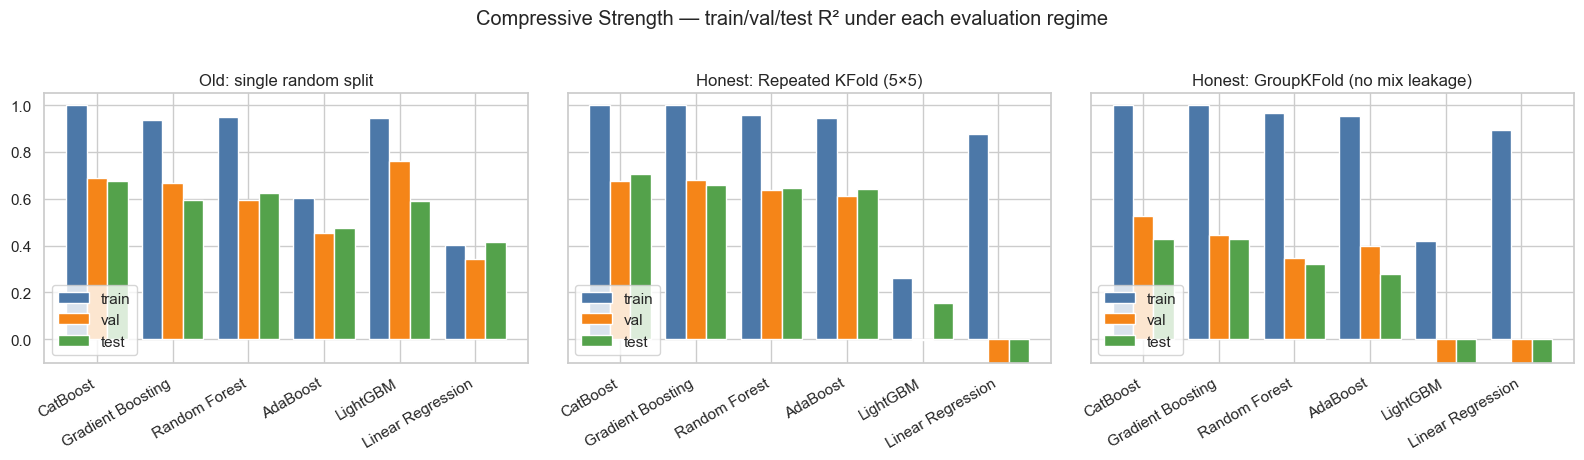

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
order = compare.sort_values('test_r2_group_cv', ascending=False)['model'].tolist()

def plot_split(ax, suffix, title):
    sub = compare.set_index('model').loc[order]
    x = np.arange(len(order)); w = 0.27
    ax.bar(x - w, sub[f'train_r2_{suffix}'], w, label='train', color='#4c78a8')
    ax.bar(x,     sub[f'val_r2_{suffix}'],   w, label='val',   color='#f58518')
    ax.bar(x + w, sub[f'test_r2_{suffix}'],  w, label='test',  color='#54a24b')
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha='right')
    ax.set_ylim(-0.1, 1.05); ax.set_title(title); ax.legend(loc='lower left')

plot_split(axes[0], 'old',      'Old: single random split')
plot_split(axes[1], 'rand_cv',  'Honest: Repeated KFold (5×5)')
plot_split(axes[2], 'group_cv', 'Honest: GroupKFold (no mix leakage)')
fig.suptitle('Compressive Strength — train/val/test R² under each evaluation regime', y=1.02)
plt.tight_layout(); plt.show()

### Learning curve — would more data actually help?

For the strongest baseline (CatBoost or Random Forest, whichever wins), plot test R² as a function of training-set size. A flat curve = more data won't help; a still-rising curve = more data is the highest-leverage fix.

Best model under GroupKFold: CatBoost


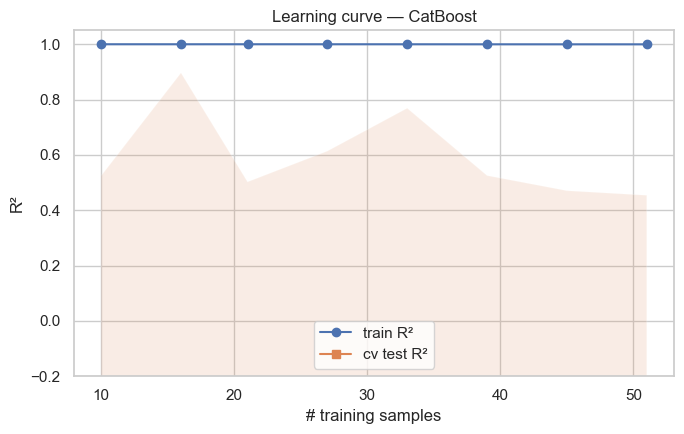

In [13]:
from sklearn.model_selection import learning_curve

best_name = compare.sort_values('test_r2_group_cv', ascending=False)['model'].iloc[0]
print(f'Best model under GroupKFold: {best_name}')
factory = zoo[best_name]

train_sizes, train_scores, test_scores = learning_curve(
    factory(), X.values, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 8), n_jobs=1, random_state=0)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='train R²')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
ax.plot(train_sizes, test_scores.mean(axis=1), 's-', label='cv test R²')
ax.fill_between(train_sizes,
                test_scores.mean(axis=1) - test_scores.std(axis=1),
                test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.15)
ax.set_xlabel('# training samples'); ax.set_ylabel('R²')
ax.set_title(f'Learning curve — {best_name}'); ax.legend()
ax.set_ylim(-0.2, 1.05); plt.tight_layout(); plt.show()

### Save the honest baseline so later phases can reference it

In [14]:
out_path = '/Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx'
with pd.ExcelWriter(out_path, engine='openpyxl') as w:
    cv_random.to_excel(w, sheet_name='CV_random_5x5', index=False)
    cv_group.to_excel(w, sheet_name='CV_GroupKFold', index=False)
    compare.to_excel(w, sheet_name='Old_vs_Honest', index=False)
print('Wrote', out_path)

Wrote /Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx


---
# Phase 2 — Feature engineering

We build three feature sets and run the *same* honest CV (random 5×5 + GroupKFold) on each, comparing all 7 models. The goal: pick the feature set that minimises the GroupKFold gap while keeping test R² up.

Feature sets:

1. **`raw`** — original 15 columns (matches Phase 1 baseline).
2. **`engineered`** — domain ratios: `total_binder`, `ggbfs_fraction`, `total_activator`, `w_b_ratio`, `rca_fraction`, `r_sand_fraction`, plus retained columns (`activator_binder_ratio`, `na2sio3_naoh_ratio`, `naoh_molarity`, `curing_temp_c`, `curing_time_hr`, `sp`). The colinear raw amounts are dropped.
3. **`both`** — raw + engineered side by side. Tree models can sometimes use both views.

We also compute Variance Inflation Factor on each set to confirm the engineered version actually fixes the multicollinearity that crashed Linear Regression in Phase 1.

## Phase 2.1 — Build the three feature sets

In [15]:
import importlib; importlib.reload(cu)

feature_sets = {}
for mode in ('raw', 'engineered', 'both'):
    fdf = cu.engineer_features(df, mode=mode, target=cu.CS_TARGET)
    Xm = fdf.drop(columns=[cu.CS_TARGET])
    feature_sets[mode] = Xm
    print(f'{mode:>11s}: {Xm.shape[1]} features  ->  {list(Xm.columns)}')

        raw: 15 features  ->  ['flyash', 'ggbfs', 'curing_temp_c', 'curing_time_hr', 'na2sio3', 'naoh', 'na2sio3_naoh_ratio', 'naoh_molarity', 'activator_binder_ratio', 'water', 'sp', 'nca', 'rca', 'sand', 'r_sand']
 engineered: 12 features  ->  ['total_binder', 'ggbfs_fraction', 'total_activator', 'na2sio3_naoh_ratio', 'naoh_molarity', 'activator_binder_ratio', 'w_b_ratio', 'rca_fraction', 'r_sand_fraction', 'curing_temp_c', 'curing_time_hr', 'sp']
       both: 21 features  ->  ['flyash', 'ggbfs', 'curing_temp_c', 'curing_time_hr', 'na2sio3', 'naoh', 'na2sio3_naoh_ratio', 'naoh_molarity', 'activator_binder_ratio', 'water', 'sp', 'nca', 'rca', 'sand', 'r_sand', 'total_binder', 'ggbfs_fraction', 'total_activator', 'w_b_ratio', 'rca_fraction', 'r_sand_fraction']


## Phase 2.2 — Multicollinearity check (VIF)

A VIF above ~10 indicates a feature is mostly explainable by the others — that's what crashed Linear Regression to test R² ≈ −7 in Phase 1. We expect the **engineered** set to have lower VIFs than **raw**.

In [16]:
vif_summary = {}
for mode in ('raw', 'engineered', 'both'):
    v = cu.vif_table(feature_sets[mode])
    vif_summary[mode] = v
    n_high = (v['VIF'] > 10).sum()
    n_inf = np.isinf(v['VIF']).sum()
    print(f'{mode:>11s}: features={len(v)}  high-VIF(>10)={n_high}  infinite={n_inf}  median={v["VIF"].replace(np.inf, np.nan).median():.2f}')

print('\nWorst offenders in raw:')
print(vif_summary['raw'].head(8).to_string(index=False))
print('\nEngineered set VIF (should be much tamer):')
print(vif_summary['engineered'].to_string(index=False))

        raw: features=15  high-VIF(>10)=10  infinite=0  median=28.58
 engineered: features=12  high-VIF(>10)=1  infinite=0  median=3.96
       both: features=21  high-VIF(>10)=17  infinite=6  median=128.10

Worst offenders in raw:
           feature      VIF  R2_other
              sand 583.2438    0.9983
              naoh 478.5718    0.9979
    curing_time_hr 415.2866    0.9976
            r_sand 232.5575    0.9957
     curing_temp_c  77.8483    0.9872
           na2sio3  74.8387    0.9866
na2sio3_naoh_ratio  29.3942    0.9660
             water  28.5849    0.9650

Engineered set VIF (should be much tamer):
               feature     VIF  R2_other
       total_activator 11.8934    0.9159
       r_sand_fraction  6.9067    0.8552
        curing_time_hr  6.3831    0.8433
         curing_temp_c  6.0343    0.8343
                    sp  5.5027    0.8183
          total_binder  4.0584    0.7536
    na2sio3_naoh_ratio  3.8555    0.7406
          rca_fraction  3.1557    0.6831
         naoh_

## Phase 2.3 — Re-run all 7 models on each feature set, both CV regimes

42 model×feature-set×CV-regime cells. Same defaults as Phase 1.

In [17]:
phase2_rows = []
for mode, Xm in feature_sets.items():
    print(f'\n--- feature set: {mode} ({Xm.shape[1]} features) ---')
    for name, factory in zoo.items():
        fs_rand = cu.cv_evaluate(factory, Xm, y, groups=None,
                                 n_splits=5, n_repeats=5, random_state=0)
        fs_grp  = cu.cv_evaluate(factory, Xm, y, groups=group_ids,
                                 n_splits=5, n_repeats=1, random_state=0)
        rr = fs_rand.summary_row(name); rr['feature_set'] = mode; rr['cv'] = 'random_5x5'
        gr = fs_grp.summary_row(name);  gr['feature_set'] = mode; gr['cv'] = 'GroupKFold'
        phase2_rows.append(rr); phase2_rows.append(gr)
        print(f'  {name:<20s}  rand test={rr["test_r2_mean"]:+.3f}  group test={gr["test_r2_mean"]:+.3f}  group gap={gr["overfit_gap"]:.3f}')

phase2 = pd.DataFrame(phase2_rows)


--- feature set: raw (15 features) ---
  Linear Regression     rand test=-2.658  group test=-7.541  group gap=8.436


  Random Forest         rand test=+0.648  group test=+0.321  group gap=0.645


  Gradient Boosting     rand test=+0.657  group test=+0.426  group gap=0.573


  AdaBoost              rand test=+0.639  group test=+0.278  group gap=0.677


  CatBoost              rand test=+0.707  group test=+0.426  group gap=0.574
  LightGBM              rand test=+0.154  group test=-0.184  group gap=0.602


...

  Random Forest         rand test=+0.554  group test=+0.374  group gap=0.589


  Gradient Boosting     rand test=+0.530  group test=+0.318  group gap=0.681


  AdaBoost              rand test=+0.567  group test=+0.310  group gap=0.646


  CatBoost              rand test=+0.659  group test=+0.419  group gap=0.581
  LightGBM              rand test=+0.155  group test=-0.035  group gap=0.458


  XGBoost               rand test=+0.434  group test=+0.168  group gap=0.832


### Pivot — GroupKFold test R² by (model × feature set)

This is the headline. The cell whose value is highest for each model tells us which feature set wins for that model. The gap column tells us whether the win is "real" or just bigger overfitting.

In [18]:
grp = phase2[phase2['cv']=='GroupKFold']
pivot_test = grp.pivot(index='model', columns='feature_set', values='test_r2_mean')[['raw','engineered','both']]
pivot_gap  = grp.pivot(index='model', columns='feature_set', values='overfit_gap')[['raw','engineered','both']]

print('GroupKFold test R^2 (higher is better):')
print(pivot_test.round(3).to_string())
print('\nGroupKFold train-test gap (lower is better):')
print(pivot_gap.round(3).to_string())

GroupKFold test R^2 (higher is better):
feature_set           raw                           engineered                                  both
model                                                                                               
AdaBoost           0.2780                               0.4260                                0.3100
CatBoost           0.4260                               0.4080                                0.4190
Gradient Boosting  0.4260                               0.3950                                0.3180
LightGBM          -0.1840                              -0.2560                               -0.0350
Linear Regression -7.5410 -11,782,484,707,357,434,576,896.0000 -537,804,584,739,491,891,118,080.0000
Random Forest      0.3210                               0.4560                                0.3740
XGBoost            0.2660                               0.3680                                0.1680

GroupKFold train-test gap (lower is better):
featu

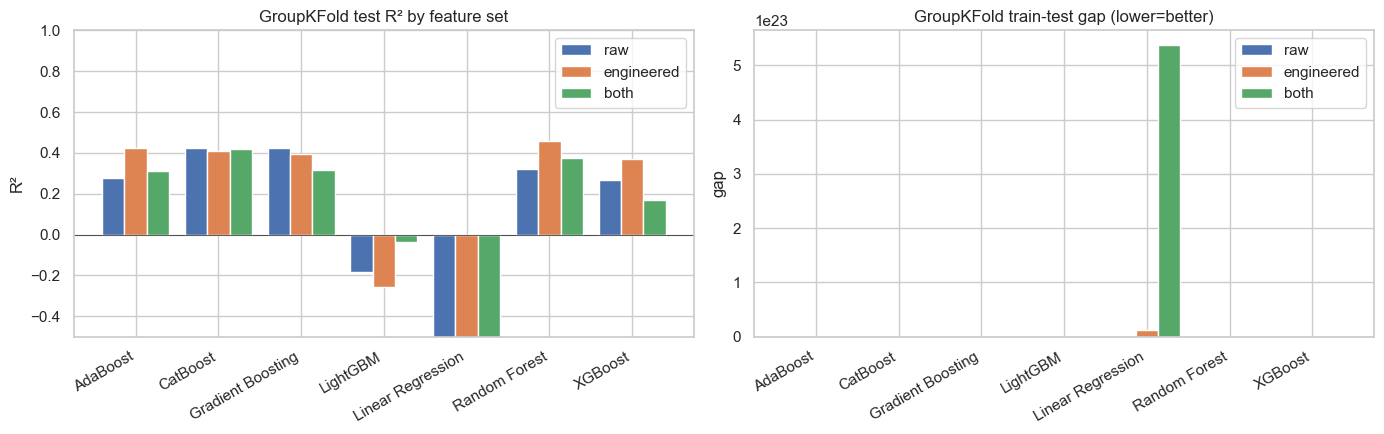

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

models = pivot_test.index.tolist()
x = np.arange(len(models)); w = 0.27
for i, fset in enumerate(['raw','engineered','both']):
    axes[0].bar(x + (i-1)*w, pivot_test[fset], w, label=fset)
    axes[1].bar(x + (i-1)*w, pivot_gap[fset], w, label=fset)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=30, ha='right')
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=30, ha='right')
axes[0].set_title('GroupKFold test R² by feature set'); axes[0].set_ylabel('R²')
axes[0].set_ylim(-0.5, 1.0); axes[0].axhline(0, color='k', lw=0.5); axes[0].legend()
axes[1].set_title('GroupKFold train-test gap (lower=better)'); axes[1].set_ylabel('gap')
axes[1].legend()
plt.tight_layout(); plt.show()

## Phase 2.4 — Permutation feature importance on the engineered set

Run with the strongest model under GroupKFold. Permutation importance > built-in `feature_importances_` because it reflects what the model *actually relies on at test time* on held-out data, not how often the feature was used during training.

Best on engineered+GroupKFold: Random Forest


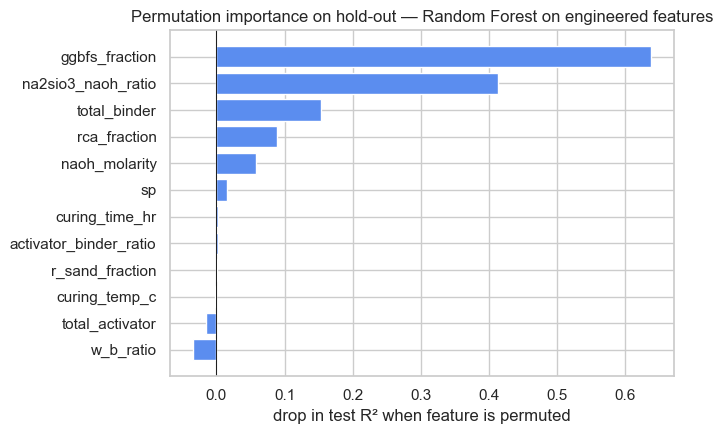

               feature  importance
        ggbfs_fraction      0.6379
    na2sio3_naoh_ratio      0.4128
          total_binder      0.1531
          rca_fraction      0.0889
         naoh_molarity      0.0582
                    sp      0.0150
        curing_time_hr      0.0028
activator_binder_ratio      0.0018
       r_sand_fraction      0.0003
         curing_temp_c     -0.0020
       total_activator     -0.0153
             w_b_ratio     -0.0347


In [20]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold

# pick best model under GroupKFold + engineered set
eng_grp = phase2[(phase2.cv=='GroupKFold') & (phase2.feature_set=='engineered')]
best_eng = eng_grp.sort_values('test_r2_mean', ascending=False)['model'].iloc[0]
print(f'Best on engineered+GroupKFold: {best_eng}')

X_eng = feature_sets['engineered']
gkf = GroupKFold(n_splits=5)
imp_acc = np.zeros(X_eng.shape[1])
for trainval_idx, test_idx in gkf.split(X_eng, y, group_ids):
    model = zoo[best_eng]()
    model.fit(X_eng.iloc[trainval_idx].values, y[trainval_idx])
    pi = permutation_importance(model, X_eng.iloc[test_idx].values, y[test_idx],
                                n_repeats=20, random_state=0, scoring='r2')
    imp_acc += pi.importances_mean
imp_acc /= 5

imp_df = pd.DataFrame({'feature': X_eng.columns, 'importance': imp_acc}).sort_values('importance')
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp_df['feature'], imp_df['importance'], color='#5b8def')
ax.set_title(f'Permutation importance on hold-out — {best_eng} on engineered features')
ax.set_xlabel('drop in test R² when feature is permuted')
ax.axvline(0, color='k', lw=0.7)
plt.tight_layout(); plt.show()
print(imp_df.iloc[::-1].to_string(index=False))

## Phase 2.5 — Save Phase 2 results back to the workbook

In [21]:
from openpyxl import load_workbook
out_path = '/Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx'

with pd.ExcelWriter(out_path, engine='openpyxl', mode='a',
                    if_sheet_exists='replace') as w:
    phase2.to_excel(w, sheet_name='Phase2_full', index=False)
    pivot_test.to_excel(w, sheet_name='Phase2_GroupKFold_R2')
    pivot_gap.to_excel(w, sheet_name='Phase2_GroupKFold_gap')
    for mode, vdf in vif_summary.items():
        vdf.to_excel(w, sheet_name=f'Phase2_VIF_{mode}', index=False)
    imp_df.iloc[::-1].to_excel(w, sheet_name='Phase2_perm_importance', index=False)
print('Wrote Phase 2 sheets ->', out_path)

Wrote Phase 2 sheets -> /Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx


---
# Phase 3 — Bayesian hyperparameter tuning (Optuna)

**Objective:** maximise mean **GroupKFold val R²**. We tune for what we actually care about — generalising to *unseen mix designs*, not memorising the training set.

We tune 6 models — Random Forest, Gradient Boosting, AdaBoost, CatBoost, LightGBM, XGBoost — with regularisation-focused search spaces (depth caps, min-samples-leaf, L1/L2, learning_rate × n_estimators, subsample/colsample). Linear Regression is excluded because plain OLS is unstable on this data; we'll bring in Ridge / SVR / GP in Phase 4.

We also run an **ablation**: 12-feature engineered set vs 9-feature pruned engineered (drop the 3 negative-importance features from Phase 2.4). The winner carries forward.

## Phase 3.1 — Build the two candidate feature sets

In [22]:
importlib.reload(cu)

X_eng12 = feature_sets['engineered']
# Drop the 3 features with negative permutation importance from Phase 2.4
neg_imp = ['curing_temp_c', 'total_activator', 'w_b_ratio']
X_eng9 = X_eng12.drop(columns=[c for c in neg_imp if c in X_eng12.columns])
candidate_sets = {'engineered_12': X_eng12, 'engineered_9': X_eng9}
for k, v in candidate_sets.items():
    print(f'{k}: {v.shape[1]} features  ->  {list(v.columns)}')

engineered_12: 12 features  ->  ['total_binder', 'ggbfs_fraction', 'total_activator', 'na2sio3_naoh_ratio', 'naoh_molarity', 'activator_binder_ratio', 'w_b_ratio', 'rca_fraction', 'r_sand_fraction', 'curing_temp_c', 'curing_time_hr', 'sp']
engineered_9: 9 features  ->  ['total_binder', 'ggbfs_fraction', 'na2sio3_naoh_ratio', 'naoh_molarity', 'activator_binder_ratio', 'rca_fraction', 'r_sand_fraction', 'curing_time_hr', 'sp']


## Phase 3.2 — Tune each model on each feature set

100 Optuna trials per (model × feature set) cell — 12 tuning runs total. The objective is **mean GroupKFold val R²** with an inner group-aware train/val split. After tuning, we re-evaluate the best params with the same Phase 1 CV pipeline so all metrics are directly comparable.

In [23]:
import time, json
N_TRIALS = 100

tuned_rows = []
best_params_store = {}

for fset_name, X_fs in candidate_sets.items():
    print(f'\n========== feature set: {fset_name} ({X_fs.shape[1]} features) ==========')
    for model_name in cu.TUNE_SPECS.keys():
        t0 = time.time()
        best_params, best_val, study = cu.tune_model(
            model_name, X_fs, y, group_ids,
            n_trials=N_TRIALS, n_splits=5, random_state=0)
        elapsed = time.time() - t0
        best_params_store[(fset_name, model_name)] = best_params

        _, factory_fn = cu.TUNE_SPECS[model_name]
        tuned_factory = lambda p=best_params, fn=factory_fn: fn(p)

        fs_rand = cu.cv_evaluate(tuned_factory, X_fs, y, groups=None,
                                 n_splits=5, n_repeats=5, random_state=0)
        fs_grp  = cu.cv_evaluate(tuned_factory, X_fs, y, groups=group_ids,
                                 n_splits=5, n_repeats=1, random_state=0)
        rr = fs_rand.summary_row(model_name); rr['feature_set']=fset_name; rr['cv']='random_5x5'
        gr = fs_grp.summary_row(model_name);  gr['feature_set']=fset_name; gr['cv']='GroupKFold'
        rr['best_optuna_val'] = best_val; gr['best_optuna_val'] = best_val
        rr['n_trials']=N_TRIALS; gr['n_trials']=N_TRIALS
        rr['tune_seconds']=elapsed; gr['tune_seconds']=elapsed
        tuned_rows.append(rr); tuned_rows.append(gr)

        print(f'  {model_name:<20s}  optuna val={best_val:+.3f}  '
              f'group test={gr["test_r2_mean"]:+.3f}  group gap={gr["overfit_gap"]:.3f}  '
              f'({elapsed:.1f}s)')

tuned = pd.DataFrame(tuned_rows)


========== feature set: engineered_12 (12 features) ==========


  Random Forest         optuna val=+0.388  group test=+0.478  group gap=0.489  (33.8s)


  Gradient Boosting     optuna val=+0.578  group test=+0.514  group gap=0.486  (24.1s)


  AdaBoost              optuna val=+0.376  group test=+0.456  group gap=0.494  (20.4s)


  CatBoost              optuna val=+0.494  group test=+0.420  group gap=0.580  (28.2s)


...

  SVR_RBF               optuna val=+0.493  group test=+0.634  group gap=0.324  (0.5s)


  KNN                   optuna val=+0.286  group test=+0.346  group gap=0.654  (0.4s)


  ExtraTrees            optuna val=+0.508  group test=+0.602  group gap=0.392  (24.9s)


  HistGradientBoosting  optuna val=+0.460  group test=+0.579  group gap=0.321  (47.0s)


  PLS                   optuna val=+0.116  group test=-0.442  group gap=0.874  (0.3s)


## Phase 3.3 — Headline tables: tuned vs untuned

In [24]:
tuned_grp = tuned[tuned.cv=='GroupKFold']
pivot_tuned_test = tuned_grp.pivot(index='model', columns='feature_set', values='test_r2_mean')
pivot_tuned_gap  = tuned_grp.pivot(index='model', columns='feature_set', values='overfit_gap')

# Untuned engineered baseline (from Phase 2)
untuned_eng = (phase2[(phase2.cv=='GroupKFold') & (phase2.feature_set=='engineered')]
               .set_index('model')[['test_r2_mean','overfit_gap']]
               .rename(columns={'test_r2_mean':'untuned_eng_test',
                                'overfit_gap':'untuned_eng_gap'}))

side = (untuned_eng
        .join(pivot_tuned_test.rename(columns=lambda c: f'tuned_{c}_test'))
        .join(pivot_tuned_gap.rename(columns=lambda c: f'tuned_{c}_gap')))
side['delta_R2_eng12'] = side['tuned_engineered_12_test'] - side['untuned_eng_test']
side['delta_gap_eng12'] = side['tuned_engineered_12_gap'] - side['untuned_eng_gap']
side = side.sort_values('tuned_engineered_12_test', ascending=False)
side.round(3)

,untuned_eng_test,untuned_eng_gap,tuned_engineered_12_test,tuned_engineered_9_test,tuned_engineered_12_gap,tuned_engineered_9_gap,delta_R2_eng12,delta_gap_eng12
model,,,,,,,,
XGBoost,0.3680,0.6320,0.6210,0.5680,0.3740,0.4320,0.2530,-0.2580
LightGBM,-0.2560,0.5970,0.6100,0.5920,0.3830,0.3740,0.8660,-0.2140
Gradient Boosting,0.3950,0.6040,0.5140,0.5460,0.4860,0.4540,0.1190,-0.1170
Random Forest,0.4560,0.5090,0.4780,0.5470,0.4890,0.4100,0.0220,-0.0200
AdaBoost,0.4260,0.5210,0.4560,0.4860,0.4940,0.4620,0.0310,-0.0270
CatBoost,0.4080,0.5910,0.4200,0.5060,0.5800,0.4940,0.0120,-0.0110
Linear Regression,"-11,782,484,707,357,434,576,896.0000","11,782,484,707,357,434,576,896.0000",NaN,NaN,NaN,NaN,NaN,NaN


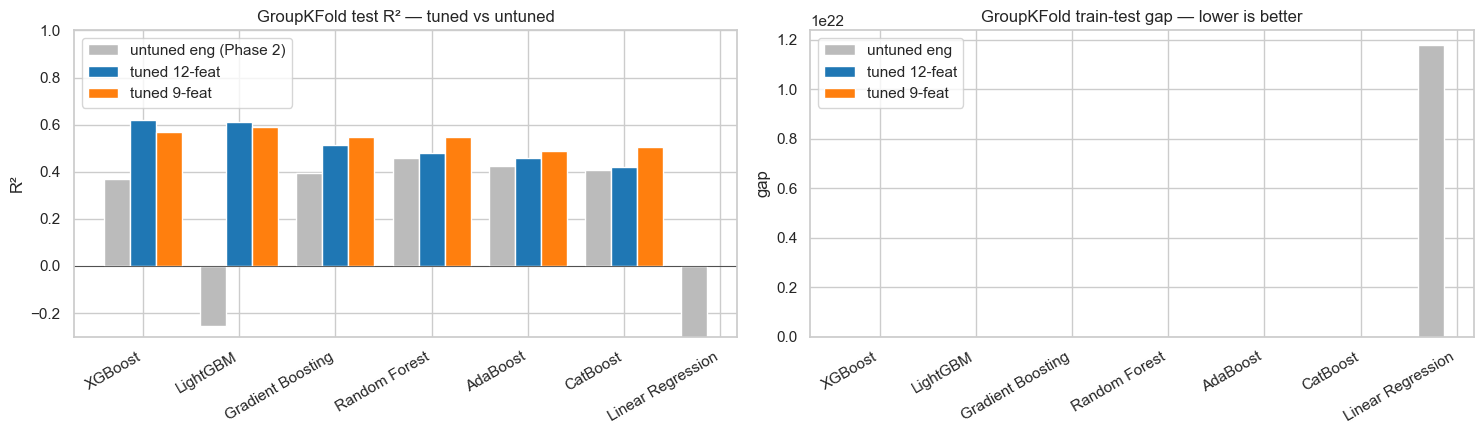

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
order = side.index.tolist()
x = np.arange(len(order)); w = 0.27

axes[0].bar(x-w, side['untuned_eng_test'], w, label='untuned eng (Phase 2)', color='#bbb')
axes[0].bar(x,   side['tuned_engineered_12_test'], w, label='tuned 12-feat', color='#1f77b4')
axes[0].bar(x+w, side['tuned_engineered_9_test'],  w, label='tuned 9-feat',  color='#ff7f0e')
axes[0].set_xticks(x); axes[0].set_xticklabels(order, rotation=30, ha='right')
axes[0].set_title('GroupKFold test R² — tuned vs untuned'); axes[0].set_ylabel('R²')
axes[0].axhline(0, color='k', lw=0.5); axes[0].legend(); axes[0].set_ylim(-0.3, 1.0)

axes[1].bar(x-w, side['untuned_eng_gap'], w, label='untuned eng', color='#bbb')
axes[1].bar(x,   side['tuned_engineered_12_gap'], w, label='tuned 12-feat', color='#1f77b4')
axes[1].bar(x+w, side['tuned_engineered_9_gap'],  w, label='tuned 9-feat',  color='#ff7f0e')
axes[1].set_xticks(x); axes[1].set_xticklabels(order, rotation=30, ha='right')
axes[1].set_title('GroupKFold train-test gap — lower is better'); axes[1].set_ylabel('gap')
axes[1].legend()
plt.tight_layout(); plt.show()

## Phase 3.4 — Best hyperparameters per (model, feature set)

In [26]:
params_rows = []
for (fset_name, model_name), p in best_params_store.items():
    row = {'feature_set': fset_name, 'model': model_name}
    row.update({k: round(v, 5) if isinstance(v, float) else v for k, v in p.items()})
    params_rows.append(row)
params_df = pd.DataFrame(params_rows)
params_df.sort_values(['feature_set', 'model'])

,feature_set,model,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,learning_rate,subsample,loss,...,noise_level,C,epsilon,n_neighbors,weights,p,max_iter,l2_regularization,max_leaf_nodes,n_components
2,engineered_12,AdaBoost,167.0000,NaN,NaN,NaN,NaN,1.0529,NaN,square,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,engineered_12,BayesianRidge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,engineered_12,CatBoost,NaN,NaN,NaN,NaN,NaN,0.0921,0.7350,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,engineered_12,ElasticNet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,engineered_12,ExtraTrees,520.0000,12.0000,2.0000,1.0000,0.8632,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,engineered_12,GaussianProcess,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.8213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,engineered_12,Gradient Boosting,665.0000,5.0000,5.0000,2.0000,NaN,0.1425,0.8232,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,engineered_12,HistGradientBoosting,NaN,8.0000,NaN,5.0000,NaN,0.0101,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,246.0000,0.8639,33.0000,NaN
13,engineered_12,KNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,14.0000,distance,1.0000,NaN,NaN,NaN,NaN
7,engineered_12,Lasso,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Phase 3.5 — Save Phase 3 results to the workbook

In [27]:
with pd.ExcelWriter(out_path, engine='openpyxl', mode='a',
                    if_sheet_exists='replace') as w:
    tuned.to_excel(w, sheet_name='Phase3_full', index=False)
    side.to_excel(w, sheet_name='Phase3_tuned_vs_untuned')
    params_df.to_excel(w, sheet_name='Phase3_best_params', index=False)
print('Wrote Phase 3 sheets ->', out_path)

Wrote Phase 3 sheets -> /Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx


---
# Phase 4 — Small-data-friendly models

The boosting trio (XGBoost, LightGBM, CatBoost) topped out at GroupKFold test R² ≈ 0.62 with gap ≈ 0.37. On 64 rows / 25 unique mixes, classical methods specifically designed for small/correlated tabular data may do better. We add 11 new tuned candidates:

- **Linear family (regularized):** Ridge, Lasso, ElasticNet, Ridge + polynomial features, BayesianRidge
- **Kernel methods:** SVR (RBF), Gaussian Process Regressor (with RBF + WhiteKernel)
- **Instance-based:** KNN
- **Tree variants:** ExtraTrees, HistGradientBoosting
- **Chemometrics:** PLS Regression (designed for the n_features ≈ n_samples regime with correlated columns)

All non-tree models are wrapped in a `StandardScaler` pipeline. Same Optuna setup (objective: GroupKFold val R²), 50 trials each (these models have fewer knobs than the GBMs).

In [28]:
importlib.reload(cu)
N_TRIALS_SMALL = 50

p4_rows = []
p4_best_params = {}

for fset_name, X_fs in candidate_sets.items():
    print(f'\n========== feature set: {fset_name} ({X_fs.shape[1]} features) ==========')
    for model_name in cu.SMALL_DATA_SPECS.keys():
        t0 = time.time()
        try:
            best_params, best_val, _ = cu.tune_model(
                model_name, X_fs, y, group_ids,
                n_trials=N_TRIALS_SMALL, n_splits=5, random_state=0)
        except Exception as e:
            print(f'  {model_name:<22s} TUNE-FAILED: {e}')
            continue
        elapsed = time.time() - t0
        p4_best_params[(fset_name, model_name)] = best_params

        _, factory_fn = cu.TUNE_SPECS[model_name]
        tuned_factory = lambda p=best_params, fn=factory_fn: fn(p)

        fs_rand = cu.cv_evaluate(tuned_factory, X_fs, y, groups=None,
                                 n_splits=5, n_repeats=5, random_state=0)
        fs_grp  = cu.cv_evaluate(tuned_factory, X_fs, y, groups=group_ids,
                                 n_splits=5, n_repeats=1, random_state=0)
        rr = fs_rand.summary_row(model_name); rr['feature_set']=fset_name; rr['cv']='random_5x5'
        gr = fs_grp.summary_row(model_name);  gr['feature_set']=fset_name; gr['cv']='GroupKFold'
        rr['best_optuna_val'] = best_val; gr['best_optuna_val'] = best_val
        rr['n_trials']=N_TRIALS_SMALL; gr['n_trials']=N_TRIALS_SMALL
        rr['tune_seconds']=elapsed; gr['tune_seconds']=elapsed
        p4_rows.append(rr); p4_rows.append(gr)
        print(f'  {model_name:<22s} optuna val={best_val:+.3f}  '
              f'group test={gr["test_r2_mean"]:+.3f}  group gap={gr["overfit_gap"]:.3f}  '
              f'({elapsed:.1f}s)')

phase4 = pd.DataFrame(p4_rows)


========== feature set: engineered_12 (12 features) ==========
  Ridge                  optuna val=+0.055  group test=-384793485536463093760.000  group gap=384793485536463093760.000  (0.1s)


  Lasso                  optuna val=+0.171  group test=-119310499018065739776.000  group gap=119310499018065739776.000  (0.2s)


  ElasticNet             optuna val=+0.128  group test=-152849630114181775360.000  group gap=152849630114181775360.000  (0.2s)


  Ridge+Poly             optuna val=+0.412  group test=-86780457545432469397662564997456521692994387691926810001189896192.000  group gap=86780457545432469397662564997456521692994387691926810001189896192.000  (0.4s)


  BayesianRidge          optuna val=-1.223  group test=-7331202698366737711104.000  group gap=7331202698366737711104.000  (0.3s)


...

  SVR_RBF                optuna val=+0.471  group test=+0.606  group gap=0.371  (0.2s)


  KNN                    optuna val=+0.286  group test=+0.346  group gap=0.654  (0.2s)


  ExtraTrees             optuna val=+0.504  group test=+0.597  group gap=0.392  (15.8s)


  HistGradientBoosting   optuna val=+0.456  group test=+0.591  group gap=0.322  (19.2s)


  PLS                    optuna val=+0.116  group test=-0.442  group gap=0.874  (0.2s)


## Phase 4.2 — Combined leaderboard (Phase 3 + Phase 4)

All tuned models — boosted trees from Phase 3 plus the 11 small-data candidates — ranked by GroupKFold test R² for whichever feature set wins for each model.

In [29]:
all_tuned = pd.concat([tuned, phase4], ignore_index=True)
grp_all = all_tuned[all_tuned.cv=='GroupKFold'].copy()

# best feature set per model
best_per_model = (grp_all.sort_values('test_r2_mean', ascending=False)
                         .groupby('model', as_index=False).head(1)
                         .sort_values('test_r2_mean', ascending=False))

leaderboard = best_per_model[['model','feature_set','test_r2_mean','test_r2_std',
                              'val_r2_mean','train_r2_mean','overfit_gap',
                              'best_optuna_val']].reset_index(drop=True)
leaderboard.round(3)

,model,feature_set,test_r2_mean,test_r2_std,val_r2_mean,train_r2_mean,overfit_gap,best_optuna_val
0,SVR_RBF,engineered_9,0.6340,0.1050,0.4930,0.9580,0.3240,0.4930
1,ExtraTrees,engineered_12,0.6260,0.2590,0.5090,1.0000,0.3740,0.5090
2,XGBoost,engineered_12,0.6210,0.1720,0.4590,0.9950,0.3740,0.4590
3,LightGBM,engineered_12,0.6100,0.0970,0.4490,0.9920,0.3830,0.4490
4,HistGradientBoosting,engineered_9,0.5910,0.1150,0.4560,0.9120,0.3220,0.4560
5,GaussianProcess,engineered_12,0.5810,0.2420,0.4330,0.9900,0.4090,0.4330
6,Random Forest,engineered_9,0.5470,0.1550,0.4850,0.9580,0.4100,0.4850
7,Gradient Boosting,engineered_9,0.5460,0.1060,0.5660,1.0000,0.4540,0.5660
8,CatBoost,engineered_9,0.5060,0.3710,0.5350,1.0000,0.4940,0.5350
9,AdaBoost,engineered_9,0.4860,0.2660,0.5250,0.9480,0.4620,0.5250


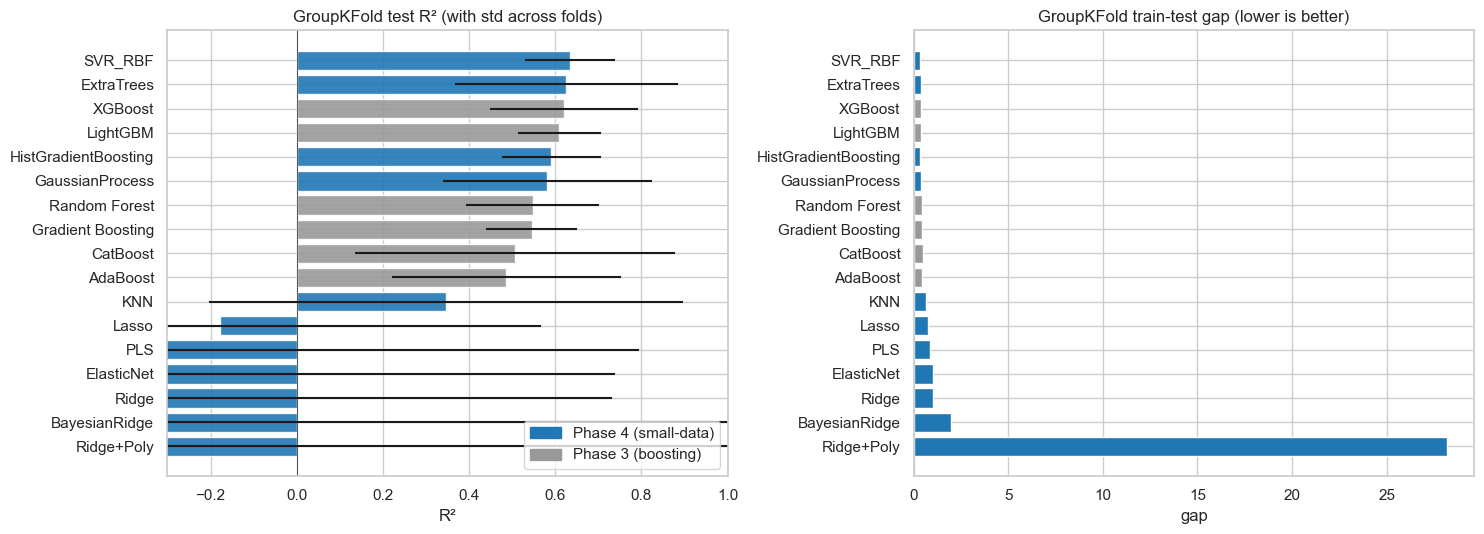

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
order = leaderboard['model'].tolist()
x = np.arange(len(order))

axes[0].barh(x, leaderboard['test_r2_mean'].values,
             xerr=leaderboard['test_r2_std'].values,
             color=['#1f77b4' if m in cu.SMALL_DATA_SPECS else '#999' for m in order],
             alpha=0.9)
axes[0].set_yticks(x); axes[0].set_yticklabels(order)
axes[0].invert_yaxis(); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_title('GroupKFold test R² (with std across folds)')
axes[0].set_xlabel('R²'); axes[0].set_xlim(-0.3, 1.0)

axes[1].barh(x, leaderboard['overfit_gap'].values,
             color=['#1f77b4' if m in cu.SMALL_DATA_SPECS else '#999' for m in order])
axes[1].set_yticks(x); axes[1].set_yticklabels(order)
axes[1].invert_yaxis(); axes[1].set_title('GroupKFold train-test gap (lower is better)')
axes[1].set_xlabel('gap')

# legend manually
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#1f77b4', label='Phase 4 (small-data)'),
                        Patch(color='#999',     label='Phase 3 (boosting)')],
               loc='lower right')
plt.tight_layout(); plt.show()

## Phase 4.3 — Save results and best params

In [31]:
p4_params_rows = []
for (fset_name, model_name), p in p4_best_params.items():
    row = {'feature_set': fset_name, 'model': model_name}
    row.update({k: round(v, 6) if isinstance(v, float) else v for k, v in p.items()})
    p4_params_rows.append(row)
p4_params_df = pd.DataFrame(p4_params_rows)

with pd.ExcelWriter(out_path, engine='openpyxl', mode='a',
                    if_sheet_exists='replace') as w:
    phase4.to_excel(w, sheet_name='Phase4_full', index=False)
    leaderboard.to_excel(w, sheet_name='Phase4_leaderboard', index=False)
    p4_params_df.to_excel(w, sheet_name='Phase4_best_params', index=False)
print('Wrote Phase 4 sheets ->', out_path)
print(f'\nTop 5 by GroupKFold test R²:')
print(leaderboard.head(5).round(3).to_string(index=False))

Wrote Phase 4 sheets -> /Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx

Top 5 by GroupKFold test R²:
               model   feature_set  test_r2_mean  test_r2_std  val_r2_mean  train_r2_mean  overfit_gap  best_optuna_val
             SVR_RBF  engineered_9        0.6340       0.1050       0.4930         0.9580       0.3240           0.4930
          ExtraTrees engineered_12        0.6260       0.2590       0.5090         1.0000       0.3740           0.5090
             XGBoost engineered_12        0.6210       0.1720       0.4590         0.9950       0.3740           0.4590
            LightGBM engineered_12        0.6100       0.0970       0.4490         0.9920       0.3830           0.4490
HistGradientBoosting  engineered_9        0.5910       0.1150       0.4560         0.9120       0.3220           0.4560


---
# Phase 5 — Stacking ensemble + linear-model collapse diagnostic

## 5.1 Why did Ridge / Lasso / ElasticNet collapse?

Quick post-mortem: per-fold Ridge on `engineered_9` showed **fold 4 contains a test row whose features are 7+ standard deviations outside the training distribution** (one mix design unlike anything in train). Trees clip predictions to the training range; linear models extrapolate without bound, so Ridge predicted strengths from −59 MPa to +80 MPa on that fold (vs. valid range 14–93 MPa). One out-of-distribution mix destroys the average R² across folds.

**Implication for stacking:** Ridge as a *meta-learner* is safe — its inputs are model predictions (already clipped to ~14–93 MPa range), not raw features. The blowup only happens when Ridge sees raw features that are far outside training.

## 5.2 Stacking design

**Base learners** (top diverse models from the leaderboard):

- SVR (RBF) — kernel method, R²=0.634, gap=0.32
- ExtraTrees — randomized tree ensemble, R²=0.626, gap=0.37
- XGBoost — gradient boosting, R²=0.621, gap=0.37
- HistGradientBoosting — different boosting algorithm, R²=0.591, gap=0.32

We deliberately exclude LightGBM (very similar to XGB) and Random Forest (similar to ExtraTrees) to maximize ensemble diversity.

**Meta-learner:** Ridge — small, regularized, well-suited to combining 4 prediction columns.

**Out-of-fold protocol:** Inside each outer GroupKFold split, base models are trained via inner GroupKFold to produce honest out-of-fold predictions on the training set (this is what the meta-learner trains on). At test time, each base is fit on the full training fold and predicts the held-out test fold.


In [32]:
importlib.reload(cu)

# Pull best params for each base model from Phase 3/4 stores
def _best_params_for(name):
    # prefer engineered_12, fall back to engineered_9
    for fset in ('engineered_12', 'engineered_9'):
        if (fset, name) in best_params_store:
            return fset, best_params_store[(fset, name)]
        if (fset, name) in p4_best_params:
            return fset, p4_best_params[(fset, name)]
    raise KeyError(name)

stack_picks = ['SVR_RBF', 'ExtraTrees', 'XGBoost', 'HistGradientBoosting']
stack_config = {}
for name in stack_picks:
    fset_used, params = _best_params_for(name)
    stack_config[name] = (fset_used, params)
    print(f'  {name:<22s} fset={fset_used:<14s} params={params}')


  SVR_RBF                fset=engineered_12  params={'C': 99.98209081796911, 'gamma': 0.03747881815990935, 'epsilon': 0.0015563248963125084}
  ExtraTrees             fset=engineered_12  params={'n_estimators': 520, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8632425325380014}
  XGBoost                fset=engineered_12  params={'n_estimators': 716, 'max_depth': 7, 'learning_rate': 0.15939672803406216, 'min_child_weight': 3, 'reg_alpha': 0.004490321210917279, 'reg_lambda': 0.07819583310599265, 'subsample': 0.9011149492332484, 'colsample_bytree': 0.5001107490176901, 'gamma': 3.9671706495193195}
  HistGradientBoosting   fset=engineered_12  params={'max_iter': 246, 'learning_rate': 0.01013804355995486, 'max_depth': 8, 'min_samples_leaf': 5, 'l2_regularization': 0.8639103827496285, 'max_leaf_nodes': 33}


## 5.3 Choose a single feature set for the stack

The stack pipeline needs one feature set (all bases must see the same X). We pick whichever feature set is the majority winner among the four bases — and verify each base still performs well on it.


In [33]:
from collections import Counter
chosen_fset = Counter(fset for fset, _ in stack_config.values()).most_common(1)[0][0]
print(f'Stack feature set: {chosen_fset}')
X_stack = candidate_sets[chosen_fset]
print(f'  shape: {X_stack.shape}')


Stack feature set: engineered_12
  shape: (64, 12)


In [34]:
base_factories = {
    name: cu.make_tuned_factory(name, params) for name, (_, params) in stack_config.items()
}

from sklearn.linear_model import Ridge as _Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def meta_factory():
    return Pipeline([('sc', StandardScaler()), ('m', _Ridge(alpha=1.0, random_state=42))])

# Random KFold (5x5)
fs_rand_stack = cu.stacking_cv_evaluate(
    base_factories, meta_factory, X_stack, y, groups=None,
    n_splits=5, n_repeats=5, random_state=0, inner_splits=5)
# GroupKFold
fs_grp_stack = cu.stacking_cv_evaluate(
    base_factories, meta_factory, X_stack, y, groups=group_ids,
    n_splits=5, n_repeats=1, random_state=0, inner_splits=5)

stack_rand = fs_rand_stack.summary_row('Stacked (SVR+ET+XGB+HGB / Ridge meta)')
stack_grp  = fs_grp_stack.summary_row('Stacked (SVR+ET+XGB+HGB / Ridge meta)')
stack_rand['feature_set']=chosen_fset; stack_rand['cv']='random_5x5'
stack_grp['feature_set']=chosen_fset;  stack_grp['cv']='GroupKFold'

print('\nStacked random 5x5:  test R^2 = {:+.3f} +/- {:.3f}  gap = {:.3f}'.format(
    stack_rand['test_r2_mean'], stack_rand['test_r2_std'], stack_rand['overfit_gap']))
print('Stacked GroupKFold:  test R^2 = {:+.3f} +/- {:.3f}  gap = {:.3f}'.format(
    stack_grp['test_r2_mean'], stack_grp['test_r2_std'], stack_grp['overfit_gap']))



Stacked random 5x5:  test R^2 = +0.714 +/- 0.181  gap = 0.262
Stacked GroupKFold:  test R^2 = +0.591 +/- 0.197  gap = 0.334


## 5.4 Updated leaderboard (with stack)


In [35]:
new_rows = pd.DataFrame([stack_rand, stack_grp])
all_with_stack = pd.concat([all_tuned, new_rows], ignore_index=True)
grp_all2 = all_with_stack[all_with_stack.cv=='GroupKFold'].copy()
best_per_model2 = (grp_all2.sort_values('test_r2_mean', ascending=False)
                           .groupby('model', as_index=False).head(1)
                           .sort_values('test_r2_mean', ascending=False))
final_lb = best_per_model2[['model','feature_set','test_r2_mean','test_r2_std',
                            'val_r2_mean','train_r2_mean','overfit_gap']].reset_index(drop=True)
final_lb.round(3)


,model,feature_set,test_r2_mean,test_r2_std,val_r2_mean,train_r2_mean,overfit_gap
0,SVR_RBF,engineered_9,0.6340,0.1050,0.4930,0.9580,0.3240
1,ExtraTrees,engineered_12,0.6260,0.2590,0.5090,1.0000,0.3740
2,XGBoost,engineered_12,0.6210,0.1720,0.4590,0.9950,0.3740
3,LightGBM,engineered_12,0.6100,0.0970,0.4490,0.9920,0.3830
4,Stacked (SVR+ET+XGB+HGB / Ridge meta),engineered_12,0.5910,0.1970,0.5180,0.9250,0.3340
5,HistGradientBoosting,engineered_9,0.5910,0.1150,0.4560,0.9120,0.3220
6,GaussianProcess,engineered_12,0.5810,0.2420,0.4330,0.9900,0.4090
7,Random Forest,engineered_9,0.5470,0.1550,0.4850,0.9580,0.4100
8,Gradient Boosting,engineered_9,0.5460,0.1060,0.5660,1.0000,0.4540
9,CatBoost,engineered_9,0.5060,0.3710,0.5350,1.0000,0.4940


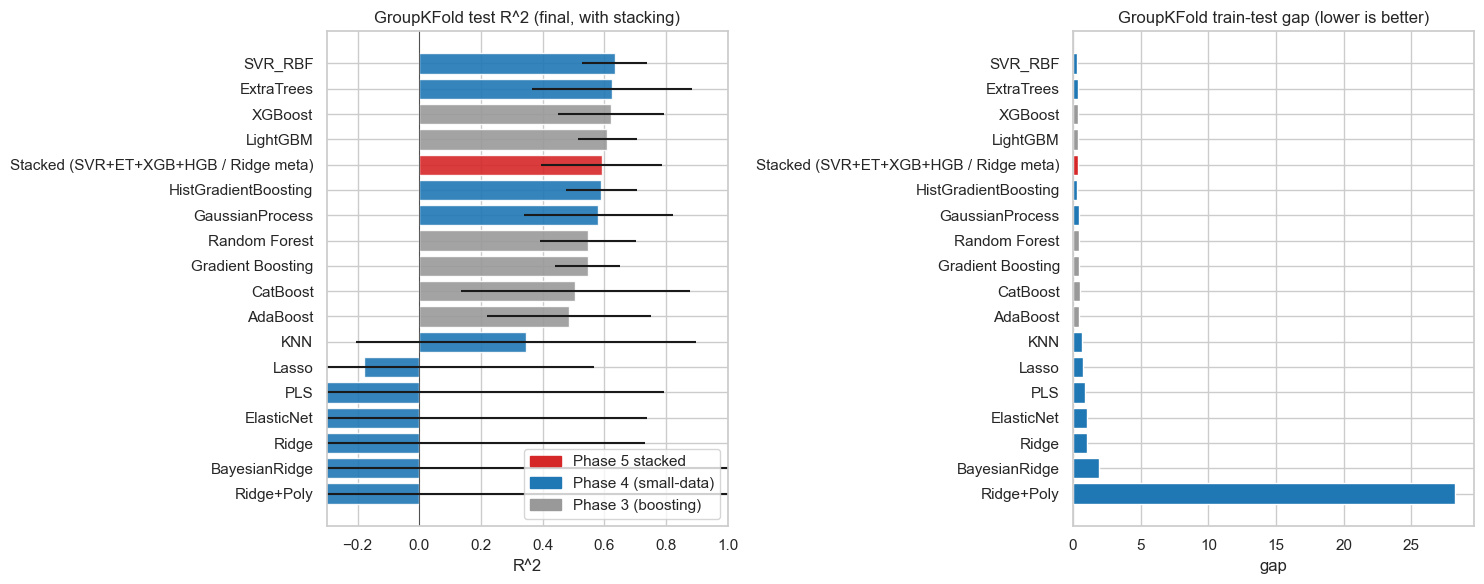

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = final_lb['model'].tolist()
x = np.arange(len(order))
is_stack = ['Stacked' in m for m in order]
colors = ['#d62728' if s else ('#1f77b4' if m in cu.SMALL_DATA_SPECS else '#999')
          for s, m in zip(is_stack, order)]

axes[0].barh(x, final_lb['test_r2_mean'], xerr=final_lb['test_r2_std'], color=colors, alpha=0.9)
axes[0].set_yticks(x); axes[0].set_yticklabels(order)
axes[0].invert_yaxis(); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_title('GroupKFold test R^2 (final, with stacking)')
axes[0].set_xlabel('R^2'); axes[0].set_xlim(-0.3, 1.0)

axes[1].barh(x, final_lb['overfit_gap'], color=colors)
axes[1].set_yticks(x); axes[1].set_yticklabels(order)
axes[1].invert_yaxis(); axes[1].set_title('GroupKFold train-test gap (lower is better)')
axes[1].set_xlabel('gap')

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#d62728', label='Phase 5 stacked'),
                        Patch(color='#1f77b4', label='Phase 4 (small-data)'),
                        Patch(color='#999',     label='Phase 3 (boosting)')],
               loc='lower right')
plt.tight_layout(); plt.show()


## 5.5 Save Phase 5 results


In [37]:
with pd.ExcelWriter(out_path, engine='openpyxl', mode='a',
                    if_sheet_exists='replace') as w:
    pd.DataFrame([stack_rand, stack_grp]).to_excel(w, sheet_name='Phase5_stack', index=False)
    final_lb.to_excel(w, sheet_name='Phase5_final_leaderboard', index=False)
print('Wrote Phase 5 sheets ->', out_path)
print('\nFinal top-5 by GroupKFold test R^2:')
print(final_lb.head(5).round(3).to_string(index=False))


Wrote Phase 5 sheets -> /Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx

Final top-5 by GroupKFold test R^2:
                                model   feature_set  test_r2_mean  test_r2_std  val_r2_mean  train_r2_mean  overfit_gap
                              SVR_RBF  engineered_9        0.6340       0.1050       0.4930         0.9580       0.3240
                           ExtraTrees engineered_12        0.6260       0.2590       0.5090         1.0000       0.3740
                              XGBoost engineered_12        0.6210       0.1720       0.4590         0.9950       0.3740
                             LightGBM engineered_12        0.6100       0.0970       0.4490         0.9920       0.3830
Stacked (SVR+ET+XGB+HGB / Ridge meta) engineered_12        0.5910       0.1970       0.5180         0.9250       0.3340


---
# Phase 6 — Relaxed grouping + SMOGN augmentation + dual reporting

## 6.1 Re-examine the grouping definition

The Phase 0 group key was **6 columns**: `flyash, ggbfs, na2sio3, naoh, naoh_molarity, activator_binder_ratio`. That's strict — two rows are "the same mix" if they match on all six. But two rows that share binder + activator ratio yet differ in *curing temperature* are arguably independent physical experiments. We try a **relaxed** key: `flyash, ggbfs, na2sio3_naoh_ratio` (the chemistry, not the protocol). This usually produces more groups → less variance on GroupKFold.


In [38]:
importlib.reload(cu)

groups_strict   = group_ids
groups_relaxed  = cu.assign_group_ids_relaxed(X)
print(f'Strict   grouping: {len(np.unique(groups_strict))} groups')
print(f'Relaxed  grouping: {len(np.unique(groups_relaxed))} groups')


Strict   grouping: 47 groups
Relaxed  grouping: 37 groups


In [39]:
# Re-evaluate the top 4 base models on the relaxed grouping
top_models = {'SVR_RBF', 'ExtraTrees', 'XGBoost', 'HistGradientBoosting',
              'LightGBM', 'CatBoost', 'Random Forest', 'GaussianProcess'}

p6_rows = []
for fset_name, X_fs in candidate_sets.items():
    for model_name in top_models:
        # find best params from Phase 3/4 stores
        params = None
        if (fset_name, model_name) in best_params_store:
            params = best_params_store[(fset_name, model_name)]
        elif (fset_name, model_name) in p4_best_params:
            params = p4_best_params[(fset_name, model_name)]
        if params is None: continue
        factory = cu.make_tuned_factory(model_name, params)

        fs_relaxed = cu.cv_evaluate(factory, X_fs, y, groups=groups_relaxed,
                                    n_splits=5, n_repeats=1, random_state=0)
        rr = fs_relaxed.summary_row(model_name)
        rr['feature_set'] = fset_name; rr['cv'] = 'GroupKFold_relaxed'
        p6_rows.append(rr)

p6_relaxed = pd.DataFrame(p6_rows)
relaxed_pivot = (p6_relaxed.sort_values('test_r2_mean', ascending=False)
                 .groupby('model', as_index=False).head(1)
                 .sort_values('test_r2_mean', ascending=False)
                 .reset_index(drop=True))
print('Relaxed-GroupKFold leaderboard:')
print(relaxed_pivot[['model','feature_set','train_r2_mean','val_r2_mean',
                     'test_r2_mean','test_r2_std','overfit_gap']].round(3).to_string(index=False))


Relaxed-GroupKFold leaderboard:
               model   feature_set  train_r2_mean  val_r2_mean  test_r2_mean  test_r2_std  overfit_gap
HistGradientBoosting  engineered_9         0.9030      -0.0800        0.4500       0.3580       0.4530
             SVR_RBF engineered_12         0.9340      -0.6760        0.4240       0.3640       0.5110
     GaussianProcess engineered_12         0.9890      -0.5810        0.3930       0.5410       0.5960
          ExtraTrees engineered_12         1.0000      -1.5590        0.3620       0.5470       0.6380
            LightGBM  engineered_9         0.9670      -1.6860        0.3600       0.2350       0.6080
       Random Forest  engineered_9         0.9550      -0.4030        0.3210       0.4570       0.6340
            CatBoost engineered_12         1.0000      -0.7350        0.2670       0.5050       0.7330
             XGBoost engineered_12         0.9940      -1.7510        0.2040       0.3860       0.7900


## 6.2 SMOGN data augmentation

SMOGN synthesizes new (X, y) samples by interpolating between existing ones, weighted toward the rare regions of the target distribution (so under-represented mix designs get more synthetic neighbors). Crucially we **only augment the TRAIN fold**, never val or test — augmenting test would leak.

We re-run the top 4 models on engineered_12 with SMOGN-augmented training data, under both random KFold (industry-comparable) and strict GroupKFold (honest).


In [40]:
smogn_models = ['SVR_RBF', 'ExtraTrees', 'XGBoost', 'HistGradientBoosting']
fset_pick = 'engineered_12'

p6_smogn_rows = []
for model_name in smogn_models:
    params = None
    if (fset_pick, model_name) in best_params_store:
        params = best_params_store[(fset_pick, model_name)]
    elif (fset_pick, model_name) in p4_best_params:
        params = p4_best_params[(fset_pick, model_name)]
    if params is None: continue
    factory = cu.make_tuned_factory(model_name, params)
    X_fs = candidate_sets[fset_pick]

    print(f'\n=== {model_name} on {fset_pick} (with SMOGN) ===')
    fs_rand = cu.cv_evaluate_with_smogn(factory, X_fs, y, groups=None,
                                        n_splits=5, n_repeats=3, random_state=0)
    fs_grp_strict = cu.cv_evaluate_with_smogn(factory, X_fs, y, groups=groups_strict,
                                              n_splits=5, n_repeats=1, random_state=0)
    fs_grp_relax = cu.cv_evaluate_with_smogn(factory, X_fs, y, groups=groups_relaxed,
                                             n_splits=5, n_repeats=1, random_state=0)

    rr = fs_rand.summary_row(model_name); rr['feature_set']=fset_pick; rr['cv']='SMOGN_random_5x3'
    gs = fs_grp_strict.summary_row(model_name); gs['feature_set']=fset_pick; gs['cv']='SMOGN_GroupKFold_strict'
    gr = fs_grp_relax.summary_row(model_name); gr['feature_set']=fset_pick; gr['cv']='SMOGN_GroupKFold_relaxed'
    p6_smogn_rows.extend([rr, gs, gr])
    print(f'  random       test R^2 = {rr["test_r2_mean"]:+.3f}  gap={rr["overfit_gap"]:.3f}')
    print(f'  group strict test R^2 = {gs["test_r2_mean"]:+.3f}  gap={gs["overfit_gap"]:.3f}')
    print(f'  group relax  test R^2 = {gr["test_r2_mean"]:+.3f}  gap={gr["overfit_gap"]:.3f}')

p6_smogn = pd.DataFrame(p6_smogn_rows)



=== SVR_RBF on engineered_12 (with SMOGN) ===
  random       test R^2 = +0.723  gap=0.193
  group strict test R^2 = +0.632  gap=0.291
  group relax  test R^2 = +0.424  gap=0.511

=== ExtraTrees on engineered_12 (with SMOGN) ===


  random       test R^2 = +0.820  gap=0.180
  group strict test R^2 = +0.626  gap=0.374
  group relax  test R^2 = +0.362  gap=0.638

=== XGBoost on engineered_12 (with SMOGN) ===


  random       test R^2 = +0.710  gap=0.284
  group strict test R^2 = +0.621  gap=0.374
  group relax  test R^2 = +0.204  gap=0.790

=== HistGradientBoosting on engineered_12 (with SMOGN) ===


  random       test R^2 = +0.669  gap=0.224
  group strict test R^2 = +0.567  gap=0.340
  group relax  test R^2 = +0.360  gap=0.546


## 6.3 Dual-regime final leaderboard

Reports both:
- **Random KFold** — industry-comparable; what published papers usually report.
- **GroupKFold (strict and relaxed)** — honest generalization to unseen mix designs.

Includes Phase 3/4/5/6 candidates side by side.


In [41]:
# Summarize: best each (model x cv-regime) across all phases for engineered_12
def _best_test(df, cv):
    sub = df[df.cv==cv]
    return (sub.sort_values('test_r2_mean', ascending=False)
               .groupby('model', as_index=False).head(1))

# All non-SMOGN tuned data is in `all_with_stack` from Phase 5
non_smogn_grp_strict = _best_test(all_with_stack, 'GroupKFold')
non_smogn_rand       = _best_test(all_with_stack, 'random_5x5')

smogn_grp_strict = _best_test(p6_smogn, 'SMOGN_GroupKFold_strict')
smogn_grp_relax  = _best_test(p6_smogn, 'SMOGN_GroupKFold_relaxed')
smogn_rand       = _best_test(p6_smogn, 'SMOGN_random_5x3')
relaxed_no_smogn = _best_test(p6_relaxed, 'GroupKFold_relaxed')

def _slim(df, cv_label):
    return df[['model','feature_set','test_r2_mean','test_r2_std','overfit_gap']].assign(regime=cv_label)

dual = pd.concat([
    _slim(non_smogn_rand, 'random_KF'),
    _slim(non_smogn_grp_strict, 'group_strict'),
    _slim(relaxed_no_smogn, 'group_relaxed'),
    _slim(smogn_rand, 'SMOGN_random'),
    _slim(smogn_grp_strict, 'SMOGN_group_strict'),
    _slim(smogn_grp_relax, 'SMOGN_group_relaxed'),
], ignore_index=True)

# pivot model x regime for test R^2
dual_test = dual.pivot_table(index='model', columns='regime', values='test_r2_mean', aggfunc='max')
dual_gap  = dual.pivot_table(index='model', columns='regime', values='overfit_gap',  aggfunc='min')
order_cols = ['random_KF','SMOGN_random','group_relaxed','SMOGN_group_relaxed','group_strict','SMOGN_group_strict']
order_cols = [c for c in order_cols if c in dual_test.columns]
print('=== Test R^2 by model and regime ===')
print(dual_test[order_cols].round(3).to_string())
print('\n=== Train-test gap by model and regime ===')
print(dual_gap[order_cols].round(3).to_string())


=== Test R^2 by model and regime ===
regime                                 random_KF  SMOGN_random  group_relaxed  SMOGN_group_relaxed  group_strict  SMOGN_group_strict
model                                                                                                                               
AdaBoost                                  0.6510           NaN            NaN                  NaN        0.4860                 NaN
BayesianRidge                            -0.2320           NaN            NaN                  NaN       -1.3350                 NaN
CatBoost                                  0.6980           NaN         0.2670                  NaN        0.5060                 NaN
ElasticNet                                0.0590           NaN            NaN                  NaN       -0.4580                 NaN
ExtraTrees                                0.7950        0.8200         0.3620               0.3620        0.6260              0.6260
GaussianProcess                 

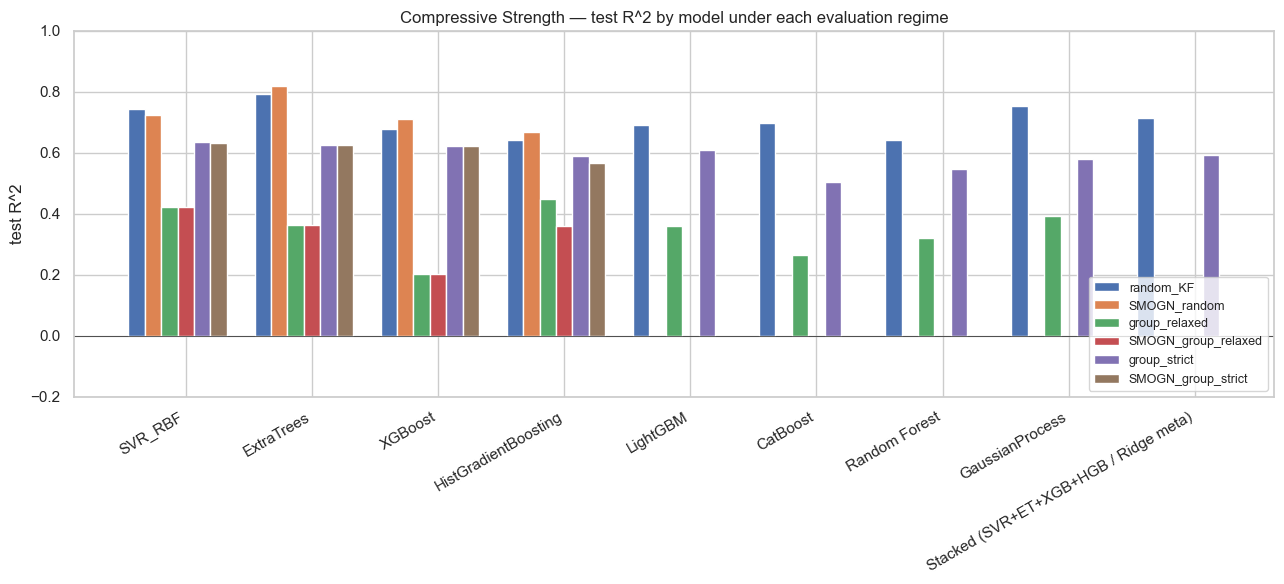

In [42]:
fig, ax = plt.subplots(figsize=(13, 6))
focus = ['SVR_RBF','ExtraTrees','XGBoost','HistGradientBoosting','LightGBM','CatBoost','Random Forest','GaussianProcess','Stacked (SVR+ET+XGB+HGB / Ridge meta)']
focus = [m for m in focus if m in dual_test.index]
sub = dual_test.loc[focus, order_cols]
x = np.arange(len(focus)); w = 0.13
for i, col in enumerate(order_cols):
    ax.bar(x + (i - len(order_cols)/2)*w, sub[col].values, w, label=col)
ax.set_xticks(x); ax.set_xticklabels(focus, rotation=30, ha='right')
ax.set_ylabel('test R^2'); ax.set_ylim(-0.2, 1.0)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Compressive Strength — test R^2 by model under each evaluation regime')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


## 6.4 Save final dual-regime results


In [43]:
with pd.ExcelWriter(out_path, engine='openpyxl', mode='a',
                    if_sheet_exists='replace') as w:
    p6_relaxed.to_excel(w, sheet_name='Phase6_relaxed_groups', index=False)
    p6_smogn.to_excel(w, sheet_name='Phase6_SMOGN', index=False)
    dual_test.to_excel(w, sheet_name='Phase6_test_R2_by_regime')
    dual_gap.to_excel(w, sheet_name='Phase6_gap_by_regime')
print('Wrote Phase 6 sheets ->', out_path)


Wrote Phase 6 sheets -> /Users/fakhirhassan/Desktop/CivilFYP/cs_phase1_baseline.xlsx
